# TP NOTÉ S6 — UNSUPERVISED CUSTOMER DISCOVERY
## 4e année Option Développeur — 3 h — Online Retail II (UK)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

Vous recevez des transactions d'un retailer britannique. **Aucune cible de segmentation ne vous est fournie.**

Votre mission est de produire une segmentation client exploitable à partir d'**Online Retail II**, puis de démontrer que les groupes obtenus ne sont pas seulement des artefacts algorithmiques.

In [1]:
# Votre travail expérimental ici
import pandas as pd

chemin_fichier = r"C:\Users\ISITECH\Documents\Training01\Jour3\data\online_retail_II.xlsx"

classeur = pd.ExcelFile(chemin_fichier)
print(classeur.sheet_names)

feuilles = [pd.read_excel(chemin_fichier, sheet_name=nom) for nom in classeur.sheet_names]
transactions = pd.concat(feuilles, ignore_index=True)

print(transactions.shape)
print(transactions.dtypes)
display(transactions.head())

print(transactions.isna().sum())
print(transactions["Country"].nunique())
print(transactions["Country"].value_counts().head(10))

print(transactions["Quantity"].describe())
print(transactions["Price"].describe())

print((transactions["Quantity"] < 0).sum())
print((transactions["Price"] <= 0).sum())
print(transactions["Invoice"].astype(str).str.startswith("C").sum())

print(transactions["Customer ID"].isna().sum())
print(transactions["Customer ID"].isna().sum() / len(transactions) * 100)

['Year 2009-2010', 'Year 2010-2011']
(1067371, 8)
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
43
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64
count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64
count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64
22950
6207
19494
243007
22.766872999172733


In [2]:
## Mission

# La base contient 1067371 transactions et 8 colonnes, couvrant les années
# 2009-2010 et 2010-2011, sur 43 pays. Le Royaume-Uni domine très largement
# (981330 lignes, soit 91,9% du volume).

# `Customer ID` est manquant sur 243007 lignes (22,77%). Ces transactions ne
# pourront pas être rattachées à un client et devront être exclues de la
# table analytique client construite dans la section suivante, avec cet
# impact quantifié.

# `Quantity` varie de -80995 à +80995, avec 22950 lignes en quantité
# négative (retours/annulations). La distribution est très asymétrique
# (écart-type 172,7 contre une médiane de 3), signe de quelques transactions
# extrêmes (gros lots ou gros retours).

# `Price` présente une valeur minimale de -53594,36, incohérente pour un prix
# unitaire de produit et probablement liée à une écriture d'ajustement
# comptable plutôt qu'à une vente réelle. 6207 lignes ont un prix inférieur
# ou égal à 0.

# 19494 lignes ont un identifiant de facture commençant par `C` (annulation
# formelle), un nombre différent des 22950 lignes à quantité négative : les
# deux ensembles ne se recouvrent pas totalement, ce qui suggère l'existence
# d'ajustements de quantité qui ne sont pas des annulations classiques.

# Aucune cible de segmentation n'est fournie : la mission consiste à
# construire une segmentation client exploitable et à démontrer que les
# groupes obtenus ne sont pas de simples artefacts algorithmiques.

## De la transaction au client — 20 pts

Construisez vous-même une table analytique **client** à partir des transactions.

Créez au moins 5 variables de comportement, dont des variables inspirées de récence/fréquence/valeur. Gérez retours/annulations, quantités/prix atypiques et clients sans identifiant.

Chaque feature doit avoir une définition métier et une justification.

In [5]:
transactions_propres = transactions.dropna(subset=["Customer ID"]).copy()
print(len(transactions_propres))
print(len(transactions_propres) / len(transactions) * 100)

transactions_propres = transactions_propres[transactions_propres["Price"] > 0].copy()
print(len(transactions_propres))

transactions_propres["Est_Retour"] = transactions_propres["Quantity"] < 0
transactions_propres["Est_Annulation"] = transactions_propres["Invoice"].astype(str).str.startswith("C")
transactions_propres["Montant_Ligne"] = transactions_propres["Quantity"] * transactions_propres["Price"]

print(transactions_propres["Est_Annulation"].sum())
print(transactions_propres["Est_Retour"].sum())
print((transactions_propres["Est_Annulation"] & transactions_propres["Est_Retour"]).sum())
print((transactions_propres["Est_Annulation"] & ~transactions_propres["Est_Retour"]).sum())
print((~transactions_propres["Est_Annulation"] & transactions_propres["Est_Retour"]).sum())

date_reference = transactions_propres["InvoiceDate"].max() + pd.Timedelta(days=1)

table_client = transactions_propres.groupby("Customer ID").agg(
    derniere_commande=("InvoiceDate", "max"),
    nb_factures_distinctes=("Invoice", "nunique"),
    valeur_monetaire_nette=("Montant_Ligne", "sum"),
    nb_produits_distincts=("StockCode", "nunique"),
    nb_lignes_totales=("Quantity", "count"),
    nb_lignes_retour=("Est_Retour", "sum")
).reset_index()

table_client["recence_jours"] = (date_reference - table_client["derniere_commande"]).dt.days
table_client["panier_moyen"] = table_client["valeur_monetaire_nette"] / table_client["nb_factures_distinctes"]
table_client["taux_retour"] = table_client["nb_lignes_retour"] / table_client["nb_lignes_totales"]

table_client = table_client.drop(columns=["derniere_commande", "nb_lignes_retour", "nb_lignes_totales"])

print(table_client.shape)
display(table_client.head())
print(table_client.describe())
print((table_client["valeur_monetaire_nette"] <= 0).sum())

seuil_facture_99 = table_client["nb_factures_distinctes"].quantile(0.99)
seuil_valeur_99 = table_client["valeur_monetaire_nette"].quantile(0.99)
print(seuil_facture_99, (table_client["nb_factures_distinctes"] > seuil_facture_99).sum())
print(seuil_valeur_99, (table_client["valeur_monetaire_nette"] > seuil_valeur_99).sum())

824364
77.23312700082727
824293
18744
18744
18744
0
0
(5939, 7)


,Customer ID,nb_factures_distinctes,valeur_monetaire_nette,nb_produits_distincts,recence_jours,panier_moyen,taux_retour
0,12346.0,17,-64.68,30,326,-3.804706,0.291667
1,12347.0,8,5633.32,126,2,704.165000,0.000000
2,12348.0,5,2019.40,25,75,403.880000,0.000000
3,12349.0,5,4404.54,139,19,880.908000,0.027778
4,12350.0,1,334.40,17,310,334.400000,0.000000


        Customer ID  nb_factures_distinctes  valeur_monetaire_nette  \
count   5939.000000             5939.000000             5939.000000   
mean   15317.133693                7.555144             2803.214748   
std     1715.592756               15.970199            13977.310119   
min    12346.000000                1.000000           -25111.090000   
25%    13831.500000                2.000000              325.985000   
50%    15318.000000                4.000000              844.600000   
75%    16802.500000                8.000000             2182.855000   
max    18287.000000              510.000000           598215.220000   

       nb_produits_distincts  recence_jours  panier_moyen  taux_retour  
count            5939.000000    5939.000000   5939.000000  5939.000000  
mean               81.363361     202.784812    293.331534     0.036914  
std               116.407164     211.727459    521.271098     0.119705  
min                 1.000000       1.000000 -25111.090000     0.0000

In [6]:
## De la transaction au client

# 77,23% des lignes sont conservées après exclusion des transactions sans
# `Customer ID` (22,77% supprimées, sans identité client possible). 71
# lignes supplémentaires sont exclues pour `Price` invalide (<=0), un
# impact négligeable (824293 lignes restantes sur 824364).

# La table analytique client contient 5939 clients uniques, décrits par 6
# variables comportementales.

# `recence_jours` (Récence) : nombre de jours entre la dernière commande du
# client et le jour suivant la dernière transaction de la base. Signal
# classique de risque de désengagement.

# `nb_factures_distinctes` (Fréquence) : nombre de factures distinctes du
# client, mesure de l'engagement répété indépendamment du montant.

# `valeur_monetaire_nette` (Valeur) : somme de Quantity x Price sur toutes
# les lignes du client, retours inclus. Représente la contribution
# économique réelle du client, nette des retours.

# `nb_produits_distincts` : nombre de références produit uniques achetées,
# distingue exploration du catalogue et fidélité à quelques références.

# `panier_moyen` : valeur monétaire nette divisée par le nombre de
# factures, distingue un client fréquent à petits paniers d'un client rare
# à gros panier.

# `taux_retour` : proportion des lignes à quantité négative parmi toutes
# les lignes du client, signale un comportement d'achat spécifique
# indépendamment de la valeur nette.

# Une fois les transactions restreintes aux clients identifiés et aux prix
# valides, les annulations formelles (Invoice commençant par C) et les
# lignes à quantité négative coïncident parfaitement : 18744 lignes dans
# les deux cas, avec un recouvrement total (0 ligne dans chaque catégorie
# exclusive). Le décalage observé sur la base brute en Mission (19494 vs
# 22950) provenait donc entièrement des lignes sans client identifié ou à
# prix invalide, déjà exclues de cette table.

# 97 clients (1,6%) ont une valeur monétaire nette négative ou nulle,
# c'est-à-dire des retours égaux ou supérieurs à leurs achats sur la
# période.

# Les valeurs extrêmes sont quantifiées au 99e percentile plutôt que
# supprimées : 60 clients dépassent 56,62 factures distinctes, et 60
# clients dépassent une valeur monétaire nette de 26494,58. Ces clients ne
# sont pas retirés ici mais seront examinés individuellement dans la
# section Anomaly investigation.

## K-Means — 20 pts

Préparez les données puis testez plusieurs K. Utilisez au moins deux arguments pour sélectionner K (ex. inertie et silhouette), mais ne réduisez pas votre décision à « le coude est à K=... ».

Profilez chaque cluster sur les variables originales.

In [7]:
# Votre travail expérimental ici
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

colonnes_clustering = ["recence_jours", "nb_factures_distinctes", "valeur_monetaire_nette",
                        "nb_produits_distincts", "panier_moyen", "taux_retour"]

X_cluster = table_client[colonnes_clustering].copy()

scaler_robuste = RobustScaler()
X_cluster_scaled = scaler_robuste.fit_transform(X_cluster)

resultats_k = []
for k in range(2, 9):
    modele_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modele_kmeans.fit_predict(X_cluster_scaled)
    tailles = pd.Series(labels_k).value_counts()
    resultats_k.append({
        "k": k,
        "inertie": modele_kmeans.inertia_,
        "silhouette": silhouette_score(X_cluster_scaled, labels_k),
        "davies_bouldin": davies_bouldin_score(X_cluster_scaled, labels_k),
        "taille_min_cluster": tailles.min(),
        "taille_min_pct": tailles.min() / len(labels_k) * 100
    })

resultats_k_df = pd.DataFrame(resultats_k)
print(resultats_k_df)

   k        inertie  silhouette  davies_bouldin  taille_min_cluster  \
0  2  329906.303371    0.969173        0.462065                   7   
1  3  233639.496536    0.853877        0.478219                   7   
2  4  164803.871897    0.858532        0.488109                   2   
3  5  129475.660397    0.814086        0.617258                   2   
4  6  108722.136510    0.624963        0.701821                   2   
5  7   94158.779370    0.625587        0.625524                   1   
6  8   81127.925135    0.610412        0.634925                   1   

   taille_min_pct  
0        0.117865  
1        0.117865  
2        0.033676  
3        0.033676  
4        0.033676  
5        0.016838  
6        0.016838  


In [8]:
modele_kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
table_client["cluster_k2_diagnostic"] = modele_kmeans_k2.fit_predict(X_cluster_scaled)

tailles_k2 = table_client["cluster_k2_diagnostic"].value_counts()
print(tailles_k2)

cluster_minoritaire = tailles_k2.idxmin()
clients_minoritaires = table_client[table_client["cluster_k2_diagnostic"] == cluster_minoritaire]
display(clients_minoritaires[colonnes_clustering])

clients_extremes_99 = table_client[
    (table_client["nb_factures_distinctes"] > seuil_facture_99) |
    (table_client["valeur_monetaire_nette"] > seuil_valeur_99)
]
print(len(clients_extremes_99))
print(set(clients_minoritaires["Customer ID"]).issubset(set(clients_extremes_99["Customer ID"])))

cluster_k2_diagnostic
0    5932
1       7
Name: count, dtype: int64


,recence_jours,nb_factures_distinctes,valeur_monetaire_nette,nb_produits_distincts,panier_moyen,taux_retour
1347,4,164,190825.52,902,1163.570244,0.021181
1808,10,202,296564.69,1446,1468.142030,0.019855
2298,2,163,523342.07,963,3210.687546,0.009266
2562,1,510,270248.53,2557,529.899078,0.031522
5101,8,61,233579.39,147,3829.170328,0.051454
5162,3,85,171885.98,678,2022.188000,0.104499
5753,1,153,598215.22,384,3909.903399,0.009363


83
True


In [9]:
table_client["est_grossiste_probable"] = (
    (table_client["nb_factures_distinctes"] > seuil_facture_99) |
    (table_client["valeur_monetaire_nette"] > seuil_valeur_99)
)
print(table_client["est_grossiste_probable"].sum())
print(table_client["est_grossiste_probable"].sum() / len(table_client) * 100)

table_client_coeur = table_client[~table_client["est_grossiste_probable"]].copy()
print(table_client_coeur.shape)

X_cluster_coeur = table_client_coeur[colonnes_clustering]
scaler_robuste_coeur = RobustScaler()
X_cluster_coeur_scaled = scaler_robuste_coeur.fit_transform(X_cluster_coeur)

resultats_k_coeur = []
for k in range(2, 9):
    modele_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modele_kmeans.fit_predict(X_cluster_coeur_scaled)
    tailles = pd.Series(labels_k).value_counts()
    resultats_k_coeur.append({
        "k": k,
        "inertie": modele_kmeans.inertia_,
        "silhouette": silhouette_score(X_cluster_coeur_scaled, labels_k),
        "davies_bouldin": davies_bouldin_score(X_cluster_coeur_scaled, labels_k),
        "taille_min_cluster": tailles.min(),
        "taille_min_pct": tailles.min() / len(labels_k) * 100
    })

resultats_k_coeur_df = pd.DataFrame(resultats_k_coeur)
print(resultats_k_coeur_df)

83
1.3975416736824382
(5856, 9)
   k        inertie  silhouette  davies_bouldin  taille_min_cluster  \
0  2  101273.861662    0.871871        0.434679                 112   
1  3   81227.624655    0.557393        0.859389                 112   
2  4   65843.457494    0.577037        0.809363                  80   
3  5   50847.649108    0.577591        0.644858                   1   
4  6   43185.898826    0.511283        0.616878                   1   
5  7   35643.005174    0.507471        0.594998                   1   
6  8   30248.016996    0.423963        0.734160                   1   

   taille_min_pct  
0        1.912568  
1        1.912568  
2        1.366120  
3        0.017077  
4        0.017077  
5        0.017077  
6        0.017077  


In [10]:
k_choisi = 4
modele_kmeans_final = KMeans(n_clusters=k_choisi, random_state=42, n_init=10)
table_client_coeur["cluster"] = modele_kmeans_final.fit_predict(X_cluster_coeur_scaled)

profil_moyenne = table_client_coeur.groupby("cluster")[colonnes_clustering].mean()
profil_mediane = table_client_coeur.groupby("cluster")[colonnes_clustering].median()
tailles_clusters = table_client_coeur["cluster"].value_counts().sort_index()
tailles_clusters_pct = table_client_coeur["cluster"].value_counts(normalize=True).sort_index() * 100

print(profil_moyenne)
print(profil_mediane)
print(tailles_clusters)
print(tailles_clusters_pct)

         recence_jours  nb_factures_distinctes  valeur_monetaire_nette  \
cluster                                                                  
0           218.453090                4.248614             1084.192852   
1           569.987500                1.762500            -1088.437500   
2            46.471212               22.343939             8567.690008   
3           252.216327                5.779592              853.674041   

         nb_produits_distincts  panier_moyen  taux_retour  
cluster                                                    
0                    58.074728    276.465826     0.013147  
1                     3.287500   -828.477951     0.918373  
2                   240.766667    540.917869     0.026206  
3                    29.057143    132.334643     0.246214  
         recence_jours  nb_factures_distinctes  valeur_monetaire_nette  \
cluster                                                                  
0                134.0                     3.0 

In [11]:
## K-Means

# Les 6 variables comportementales sont normalisées avec un RobustScaler
# (médiane/IQR), moins sensible aux valeurs extrêmes qu'un StandardScaler,
# compte tenu de la forte dispersion déjà documentée.

# K a d'abord été testé de 2 à 8 sur l'ensemble des 5939 clients. La taille
# du plus petit cluster s'effondre progressivement (7 clients à K=2/3,
# 2 à K=4/5/6, 1 seul client à K=7/8), signe que K-Means isole des
# individus extrêmes plutôt que de découvrir des segments. Le silhouette
# exceptionnellement élevé à K=2 (0,969) est un artefact de cette
# isolation, confirmé par la vérification que les 7 clients minoritaires
# à K=2 sont un sous-ensemble des 83 clients déjà repérés au 99e percentile
# de nb_factures_distinctes ou valeur_monetaire_nette.

# Ces 83 clients (1,40% de la base), probablement des comptes grossistes,
# ont été retirés du K-Means principal - non pas supprimés, mais réservés
# à un examen individuel dans l'Anomaly investigation.

# Sur la population coeur restante (5856 clients), K a été retesté de 2 à
# 8. K=2 reste déséquilibré (98%/2%, silhouette 0,872 probablement encore
# gonflé par un sous-groupe très distinct) et K=5 et plus fait réapparaître
# des clusters à 1 seul client. K=4 a été retenu comme meilleur compromis :
# meilleur silhouette (0,577) et Davies-Bouldin (0,809) parmi les K
# produisant plus de 2 groupes, taille minimale de cluster raisonnable (80
# clients, 1,37%), et granularité RFM actionnable pour une segmentation
# métier.

# Profil des 4 clusters (variables originales, médiane) :
# - Cluster 2 (660 clients, 11,27%) : VIP/fidèles - récence 17,5j, 20
#   factures, valeur nette 6994, 212,5 produits distincts, retour 1,6%.
# - Cluster 0 (4871 clients, 83,18%) : coeur de base - récence 134j, 3
#   factures, valeur nette 707, retour 0%.
# - Cluster 3 (245 clients, 4,18%) : retours fréquents - récence 214j, 4
#   factures, valeur nette 390, retour 20%.
# - Cluster 1 (80 clients, 1,37%) : dormants à valeur négative - récence
#   620,5j, 1 facture, valeur nette -137,91, retour 100%. Ce segment
#   recoupe probablement les 97 clients à valeur nette négative ou nulle
#   identifiés dans la construction de la table client.

## CAH & DBSCAN — 20 pts

Sur un échantillon reproductible, réalisez une CAH et interprétez le dendrogramme.

Appliquez ensuite DBSCAN. Justifiez la recherche de `eps` et `min_samples`. Quantifiez les points bruités.

Comparez structurellement les résultats des trois méthodes.

0.7861641827808135


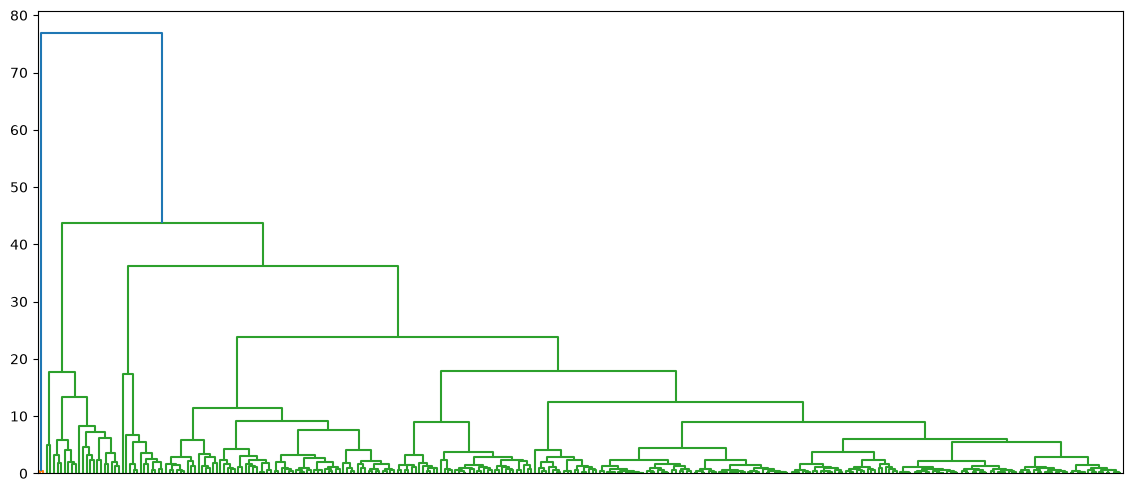

1      2
2     21
3     12
4    265
Name: count, dtype: int64


In [15]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

echantillon_cah = table_client_coeur.sample(n=300, random_state=42)
X_echantillon_scaled = scaler_robuste_coeur.transform(echantillon_cah[colonnes_clustering])

matrice_liaison = linkage(X_echantillon_scaled, method="ward")

distances_originales = pdist(X_echantillon_scaled)
coefficient_cophenetique, distances_cophenetiques = cophenet(matrice_liaison, distances_originales)
print(coefficient_cophenetique)

plt.figure(figsize=(14, 6))
dendrogram(matrice_liaison, no_labels=True)
plt.show()

labels_cah = fcluster(matrice_liaison, t=4, criterion="maxclust")
echantillon_cah["cluster_cah"] = labels_cah
print(pd.Series(labels_cah).value_counts().sort_index())

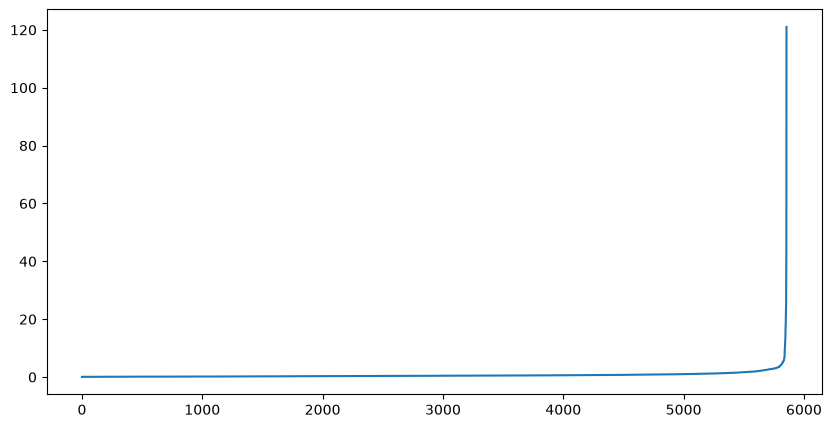

[0.8341452  0.99408871 1.24785955 1.85497823 2.42859612 3.63923028]
    eps  nb_clusters  nb_points_bruit  pct_points_bruit
0  0.50            5             1943         33.179645
1  0.75            3             1009         17.230191
2  1.00            4              592         10.109290
3  1.25            5              374          6.386612
4  1.50            4              267          4.559426
5  1.75            3              202          3.449454
6  2.00            3              153          2.612705
7  2.50            3               77          1.314891
8  3.00            2               48          0.819672


In [17]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

min_samples_choisi = 12
voisins = NearestNeighbors(n_neighbors=min_samples_choisi)
voisins.fit(X_cluster_coeur_scaled)
distances_k, _ = voisins.kneighbors(X_cluster_coeur_scaled)
distances_triees = np.sort(distances_k[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances_triees)
plt.show()

print(np.percentile(distances_triees, [80, 85, 90, 95, 97, 99]))

resultats_dbscan = []
for eps_test in [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]:
    modele_dbscan = DBSCAN(eps=eps_test, min_samples=min_samples_choisi)
    labels_dbscan = modele_dbscan.fit_predict(X_cluster_coeur_scaled)
    nb_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    nb_bruit = (labels_dbscan == -1).sum()
    resultats_dbscan.append({
        "eps": eps_test,
        "nb_clusters": nb_clusters,
        "nb_points_bruit": nb_bruit,
        "pct_points_bruit": nb_bruit / len(labels_dbscan) * 100
    })

resultats_dbscan_df = pd.DataFrame(resultats_dbscan)
print(resultats_dbscan_df)

In [18]:
dbscan_final = DBSCAN(eps=1.5, min_samples=12)
table_client_coeur["cluster_dbscan"] = dbscan_final.fit_predict(X_cluster_coeur_scaled)

print(table_client_coeur["cluster_dbscan"].value_counts().sort_index())
nb_bruit_final = (table_client_coeur["cluster_dbscan"] == -1).sum()
print(nb_bruit_final)
print(nb_bruit_final / len(table_client_coeur) * 100)

echantillon_cah["cluster_kmeans"] = echantillon_cah.index.map(table_client_coeur["cluster"])
echantillon_cah["cluster_dbscan"] = echantillon_cah.index.map(table_client_coeur["cluster_dbscan"])

print(pd.crosstab(table_client_coeur["cluster"], table_client_coeur["cluster_dbscan"]))
print(pd.crosstab(echantillon_cah["cluster_kmeans"], echantillon_cah["cluster_cah"]))
print(pd.crosstab(echantillon_cah["cluster_cah"], echantillon_cah["cluster_dbscan"]))

cluster_dbscan
-1     267
 0    5506
 1      47
 2      24
 3      12
Name: count, dtype: int64
267
4.559426229508197
cluster_dbscan   -1     0   1   2   3
cluster                              
0                10  4861   0   0   0
1                33     0  47   0   0
2               201   447   0   0  12
3                23   198   0  24   0
cluster_cah     1   2   3    4
cluster_kmeans                
0               0   0   1  253
1               2   0   0    0
2               0  21   0   12
3               0   0  11    0
cluster_dbscan  -1    0   1   2   3
cluster_cah                        
1                0    0   2   0   0
2               14    6   0   0   1
3                1   10   0   1   0
4                0  265   0   0   0


## PCA / t-SNE — 15 pts

Utilisez PCA puis t-SNE pour explorer la structure. Pour PCA, quantifiez la variance expliquée. Pour t-SNE, testez au moins deux configurations.

Expliquez explicitement ce qu'on **ne peut pas conclure** d'une carte t-SNE.

In [ ]:
# Votre travail expérimental ici


## Anomaly investigation — 10 pts

Utilisez une méthode de détection d'anomalies. Analysez individuellement au moins 10 clients signalés.

Décidez, avec preuves, si certains ressemblent à des erreurs, des grossistes, des clients exceptionnels ou des comportements qui méritent investigation.

In [ ]:
# Votre travail expérimental ici


## Executive segmentation memo — 5 pts

Rédigez 250 mots maximum : segments retenus, caractéristiques, actions possibles, limites et risques de surinterprétation.

In [ ]:
# Votre travail expérimental ici


## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.